# cdna3 Attention Kernel — Index Arithmetic Tour

This notebook walks through every index calculation in `attention_kernel.hip`
with diagrams and concrete examples.

**Constants used throughout**

| Name | Value | Meaning |
|------|-------|---------|
| `kWaveSize` | 64 | threads per wave |
| `kNumWaves` | 4 | waves per CTA |
| `kBlockSize` | 256 | threads per CTA |
| `kNBlock` | 64 | KV rows per K-block |
| `kKTile` | 16 | MFMA tile edge (rows/cols) |
| `kHeadDim` | 128 | head dimension |
| `kDTiles` | 8 | head-dim tiles (128/16) |
| `kNSub` | 4 | KV sub-tiles per K-block (64/16) |
| `kHalfDim` | 64 | half of head dim |
| `kLdsStride` | 68 | LDS row stride (padded to avoid bank conflicts) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── kernel constants ──────────────────────────────────────────────────────────
kWaveSize = 64
kNumWaves = 4
kBlockSize = kWaveSize * kNumWaves  # 256
kNBlock = 64
kNSub = 4  # kNBlock / kKTile
kKTile = 16
kHeadDim = 128
kDTiles = kHeadDim // kKTile  # 8
kHalfDim = kHeadDim // 2  # 64
kLdsStride = 68

print(f"Block: {kBlockSize} threads = {kNumWaves} waves × {kWaveSize} lanes")
print(f"Each wave processes 2 Q tiles × {kKTile} rows = {2 * kKTile} Q rows/wave")
print(
    f"Each CTA  processes {kNumWaves * 2} Q tiles = {kNumWaves * 2 * kKTile} Q rows/CTA"
)

Block: 256 threads = 4 waves × 64 lanes
Each wave processes 2 Q tiles × 16 rows = 32 Q rows/wave
Each CTA  processes 8 Q tiles = 128 Q rows/CTA


---
## 1 · Grid & thread decomposition

```
grid.x  = ceil(q_tiles / (kNumWaves * 2))   — groups of 8 Q-tiles
grid.y  = batch * heads
```

Within a CTA:
```
wid  = tid >> 6       — wave index 0..3
lane = tid & 63       — lane within wave 0..63
col  = lane & 15      — 0..15  (MFMA "column" dimension)
quad = lane >> 4      — 0..3   (which group-of-16 lanes)
```

The 16×16×16 bf16 MFMA (`mfma_f32_16x16x16bf16_1k`) hands every lane
**4 A-elements** (one row, 4 consecutive K positions) and **4 B-elements**
(one column, 4 consecutive K positions).  
The 64 lanes split into 4 quads of 16; each quad covers 4 adjacent K positions.

/tmp/ipykernel_3847087/3535513644.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap4 = plt.cm.get_cmap('tab10', 4)


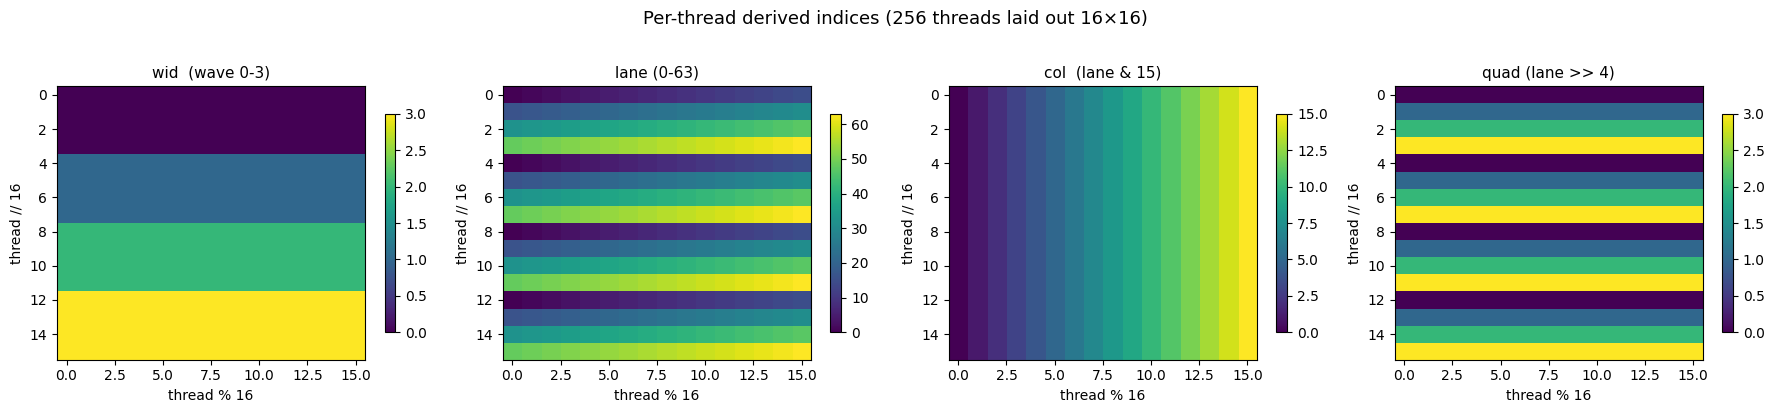

In [2]:
# Build the per-lane derived indices for all 256 threads
tids = np.arange(kBlockSize)
wids = tids >> 6
lanes = tids & 63
cols = lanes & 15
quads = lanes >> 4

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
cmap4 = plt.cm.get_cmap("tab10", 4)

labels = ["wid  (wave 0-3)", "lane (0-63)", "col  (lane & 15)", "quad (lane >> 4)"]
data = [wids, lanes, cols, quads]
vmaxs = [3, 63, 15, 3]

for ax, d, lbl, vm in zip(axes, data, labels, vmaxs):
    im = ax.imshow(
        d.reshape(16, 16),
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=vm,
        interpolation="nearest",
    )
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("thread % 16")
    ax.set_ylabel("thread // 16")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(
    "Per-thread derived indices (256 threads laid out 16×16)", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

---
## 2 · Q-tile assignment per wave

```cpp
// Each CTA covers kNumWaves*2 = 8 consecutive 16-row Q tiles.
// blockIdx.x selects the group of 8; wid*2 picks this wave's lo/hi pair.
const int qtile_base = blockIdx.x * kNumWaves * 2 + wid * 2;
const bool valid[2]  = {qtile_base < q_tiles, qtile_base + 1 < q_tiles};
// tile index → absolute first row  (× 16 rows/tile)
const int  qbase[2]  = {valid[0] ? qtile_base * 16       : 0,
                        valid[1] ? (qtile_base + 1) * 16 : 0};
```

Wave assignments within one CTA (`blockIdx.x = B`):

| wave | qtile_base | lo tile | hi tile | lo rows | hi rows |
|------|-----------|---------|---------|---------|--------|
| 0 | 8B+0 | 8B+0 | 8B+1 | 16(8B+0)..+15 | 16(8B+1)..+15 |
| 1 | 8B+2 | 8B+2 | 8B+3 | 16(8B+2)..+15 | 16(8B+3)..+15 |
| 2 | 8B+4 | 8B+4 | 8B+5 | 16(8B+4)..+15 | 16(8B+5)..+15 |
| 3 | 8B+6 | 8B+6 | 8B+7 | 16(8B+6)..+15 | 16(8B+7)..+15 |

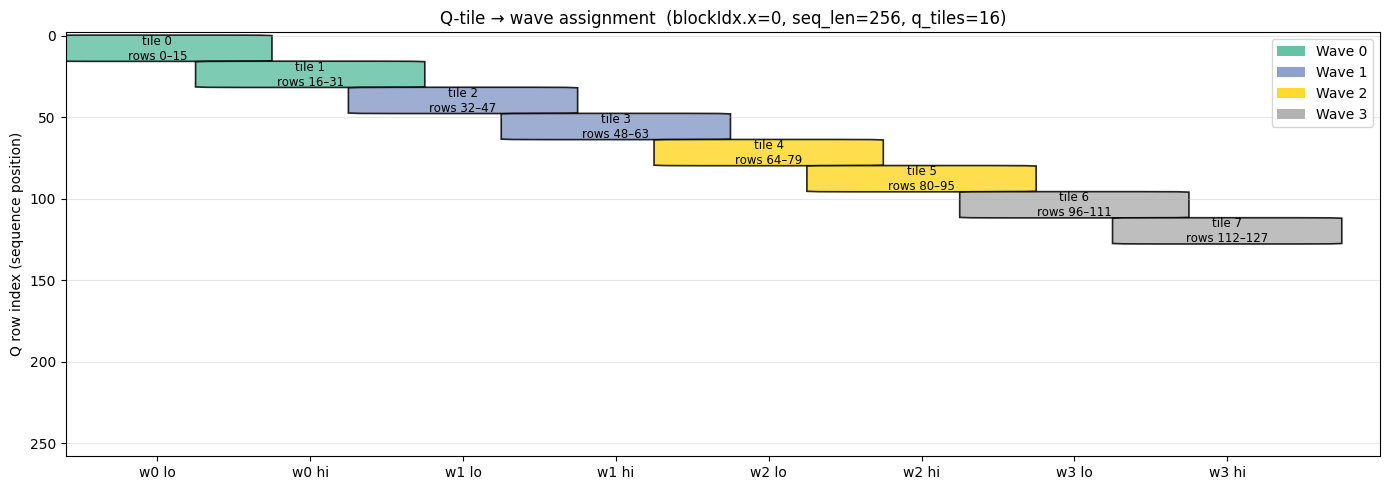

In [3]:
# Visualise for a concrete example: blockIdx.x = 0, seq_len = 256 → q_tiles = 16
seq_len = 256
q_tiles = seq_len // kKTile  # 16
blockIdx_x = 0

fig, ax = plt.subplots(figsize=(14, 5))

wave_colors = plt.cm.Set2(np.linspace(0, 1, kNumWaves))
tile_h = 16  # rows per tile

for wid in range(kNumWaves):
    qtile_base = blockIdx_x * kNumWaves * 2 + wid * 2
    for qg in range(2):
        tile_idx = qtile_base + qg
        valid = tile_idx < q_tiles
        row_start = tile_idx * tile_h
        lbl = f"wave {wid} {'lo' if qg == 0 else 'hi'}" if valid else None
        alpha = 0.85 if valid else 0.2
        rect = mpatches.FancyBboxPatch(
            (wid * 2 + qg - 0.45, row_start),
            0.9,
            tile_h - 0.5,
            boxstyle="round,pad=0.3",
            facecolor=wave_colors[wid],
            edgecolor="black",
            alpha=alpha,
            linewidth=1.2,
        )
        ax.add_patch(rect)
        if valid:
            ax.text(
                wid * 2 + qg,
                row_start + tile_h / 2,
                f"tile {tile_idx}\nrows {row_start}–{row_start + tile_h - 1}",
                ha="center",
                va="center",
                fontsize=8.5,
            )

ax.set_xlim(-0.6, 8)
ax.set_ylim(-2, seq_len + 2)
ax.invert_yaxis()
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels(
    ["w0 lo", "w0 hi", "w1 lo", "w1 hi", "w2 lo", "w2 hi", "w3 lo", "w3 hi"]
)
ax.set_ylabel("Q row index (sequence position)")
ax.set_title(
    f"Q-tile → wave assignment  (blockIdx.x={blockIdx_x}, seq_len={seq_len}, q_tiles={q_tiles})"
)
patches = [
    mpatches.Patch(facecolor=wave_colors[i], label=f"Wave {i}") for i in range(4)
]
ax.legend(handles=patches, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3 · Q register load — byte-offset arithmetic

```cpp
bld8(qr, ((qbase[qg] + col) * kHeadDim + d * kKTile + 4 * quad) * 2)
```

This is a **flat bf16 row-major matrix** with shape `[seq_len, kHeadDim]`.  
Each `bld8` fetches **8 bytes = 4 consecutive bf16** values.

```
row        = qbase[qg] + col          — absolute row in Q
                col = lane & 15
                → 16 lanes within a quad all address different rows
                   of the same MFMA tile

elem_start = d * kKTile + 4 * quad    — first element within the row
                d    ∈ [0, kDTiles)   → which 16-wide head-dim tile
                quad ∈ [0, 4)         → which 4-elem group inside that tile
                                         (offsets 0, 4, 8, 12)

byte_off   = (row * kHeadDim + elem_start) * 2
```

The 4×16 = 64 lanes of one wave together cover the **entire** 16×16 tile of A
for one (d, qg) combination.

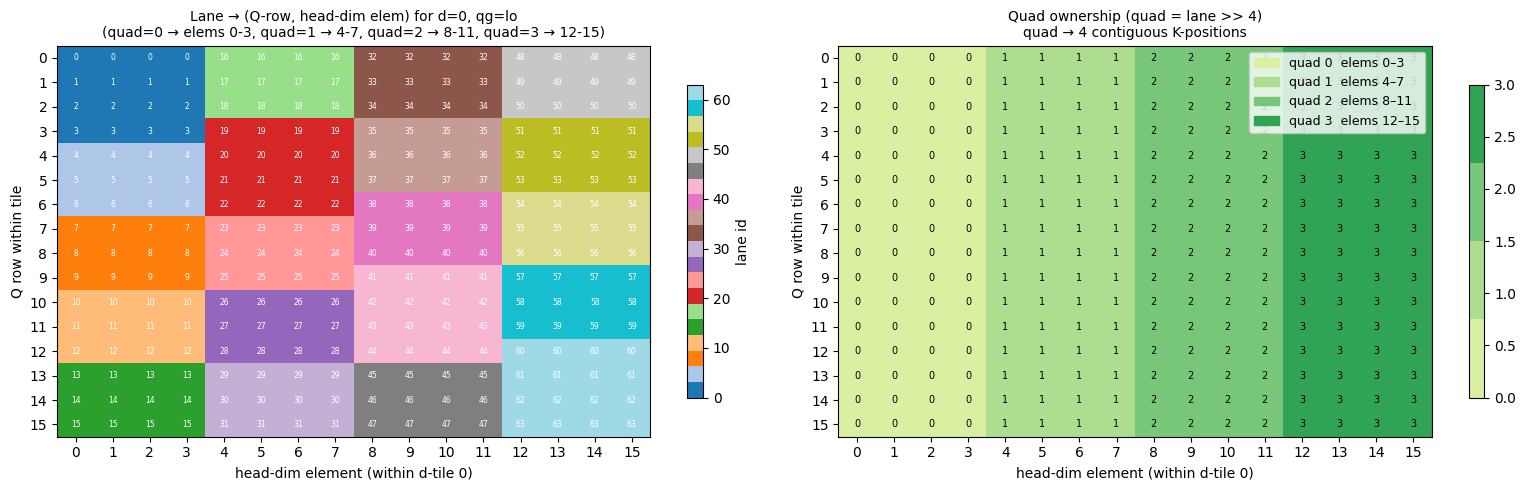

Each lane loads exactly 4 adjacent elements along the K (head-dim) axis for one Q row.
All 64 lanes together tile the full 16×16 block = one MFMA A-matrix tile.


In [4]:
# For wave 0, qg=0 (lo tile), tile 0 (qbase=0):
# Show which (row, elem) each of the 64 lanes is responsible for, for d=0.

qbase_lo = 0  # first row of lo tile
d = 0  # first d-tile

rows_loaded = np.zeros((kKTile, kKTile), dtype=int)  # 16 rows × 16 head-dim elem
lane_map = np.full((kKTile, kKTile), -1, dtype=int)

for lane in range(kWaveSize):
    col = lane & 15
    quad = lane >> 4
    row = qbase_lo + col  # row within tile (0..15)
    elem = d * kKTile + 4 * quad  # absolute elem in head dim
    elem_local = elem - d * kKTile  # relative to tile (0,4,8,12)
    # each lane loads 4 consecutive elems: elem_local, elem_local+1, +2, +3
    for k in range(4):
        lane_map[row, elem_local + k] = lane

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: which lane loads each (row, elem) cell
ax = axes[0]
im = ax.imshow(
    lane_map, aspect="auto", cmap="tab20", vmin=0, vmax=63, interpolation="nearest"
)
ax.set_title(
    f"Lane → (Q-row, head-dim elem) for d={d}, qg=lo\n(quad=0 → elems 0-3, quad=1 → 4-7, quad=2 → 8-11, quad=3 → 12-15)",
    fontsize=10,
)
ax.set_xlabel("head-dim element (within d-tile 0)")
ax.set_ylabel("Q row within tile")
ax.set_xticks(range(16))
ax.set_yticks(range(16))
plt.colorbar(im, ax=ax, label="lane id", shrink=0.8)

# Annotate with lane number
for r in range(kKTile):
    for e in range(kKTile):
        ax.text(
            e,
            r,
            str(lane_map[r, e]),
            ha="center",
            va="center",
            fontsize=5.5,
            color="white",
        )

# Right: quad ownership
quad_map = lane_map >> 4  # lane // 16
quad_map[lane_map == -1] = -1
ax2 = axes[1]
cmap_q = ListedColormap(["#d9f0a3", "#addd8e", "#78c679", "#31a354"])
im2 = ax2.imshow(
    quad_map, aspect="auto", cmap=cmap_q, vmin=0, vmax=3, interpolation="nearest"
)
ax2.set_title(
    "Quad ownership (quad = lane >> 4)\nquad → 4 contiguous K-positions", fontsize=10
)
ax2.set_xlabel("head-dim element (within d-tile 0)")
ax2.set_ylabel("Q row within tile")
ax2.set_xticks(range(16))
ax2.set_yticks(range(16))
for r in range(kKTile):
    for e in range(kKTile):
        ax2.text(e, r, str(quad_map[r, e]), ha="center", va="center", fontsize=7)
patches2 = [
    mpatches.Patch(color=cmap_q(i / 3), label=f"quad {i}  elems {4 * i}–{4 * i + 3}")
    for i in range(4)
]
ax2.legend(handles=patches2, loc="upper right", fontsize=9)
plt.colorbar(im2, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

print(
    "Each lane loads exactly 4 adjacent elements along the K (head-dim) axis for one Q row."
)
print("All 64 lanes together tile the full 16×16 block = one MFMA A-matrix tile.")

---
## 4 · K/V thread mapping

K and V are loaded cooperatively by all 256 threads.  
Each thread is assigned one row of the KV block and one 16-element column slice:

```cpp
kvrow = tid >> 2          // 0..63  — which KV row this thread covers
kcol  = (tid & 3) * 16   // 0,16,32,48 — 16-element K column slice
vdim  = (tid & 3) * 8    //  0, 8,16,24 — 8-element V head-dim slice
```

So the 256 threads split into:
- **64 kvrow groups** × **4 threads each** (tid&3 = 0..3)
- Each group of 4 covers the full 64-element head-dim in `kcol` (4×16=64) or `vdim` (4×8=32).

Note: K is loaded in two halves via `issue_k(nb, h=0|1, ...)` each covering `kHalfDim=64` elements.

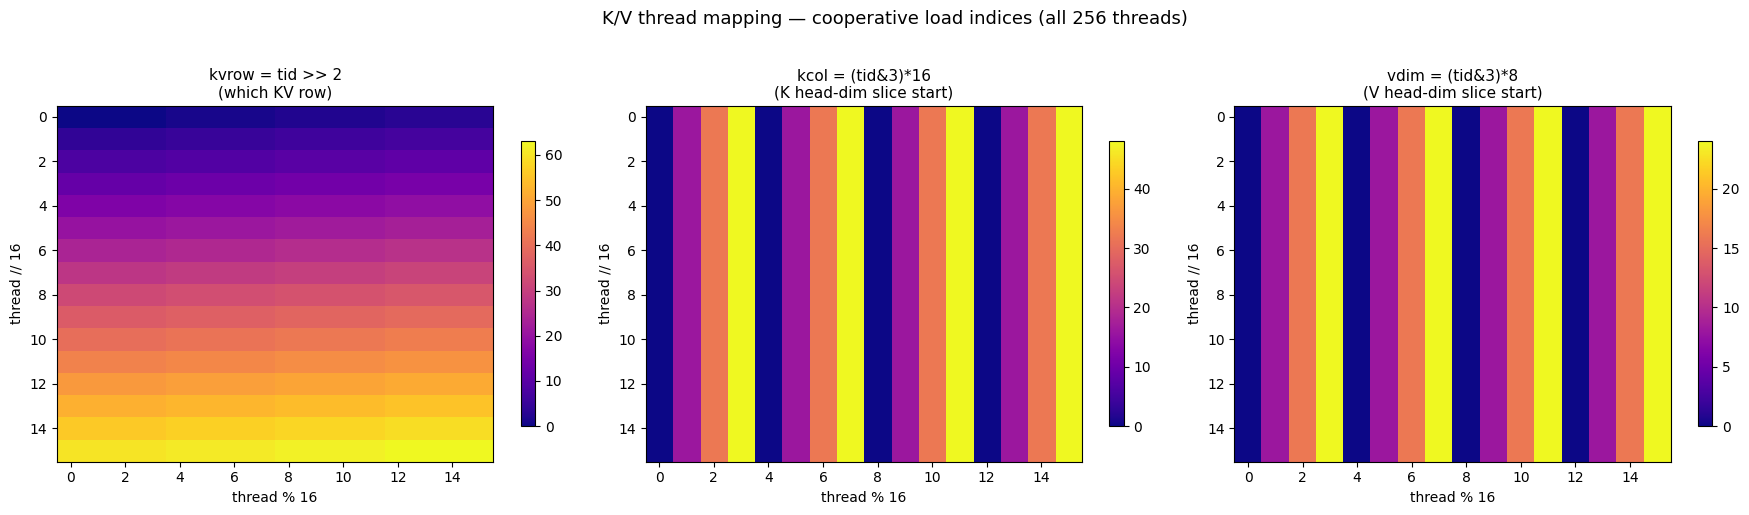

In [5]:
tids_all = np.arange(kBlockSize)
kvrows = tids_all >> 2
kcols = (tids_all & 3) * 16
vdims = (tids_all & 3) * 8

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, d, lbl, vm in zip(
    axes,
    [kvrows, kcols, vdims],
    [
        "kvrow = tid >> 2\n(which KV row)",
        "kcol = (tid&3)*16\n(K head-dim slice start)",
        "vdim = (tid&3)*8\n(V head-dim slice start)",
    ],
    [63, 48, 24],
):
    im = ax.imshow(
        d.reshape(16, 16),
        aspect="auto",
        cmap="plasma",
        vmin=0,
        vmax=vm,
        interpolation="nearest",
    )
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("thread % 16")
    ax.set_ylabel("thread // 16")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(
    "K/V thread mapping — cooperative load indices (all 256 threads)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## 5 · K global → LDS layout

### 5a · Global load address (`issue_k`)

```cpp
// K is stored row-major: K[seq_len, kHeadDim] — flat bf16
// Each call to issue_k loads one 128-bit chunk (bf16x8 = 16 bytes) twice,
// covering 16 head-dim elements from one KV row.
int base = (nb * kNBlock + kvrow) * kHeadDim * 2;   // byte offset to this KV row
int dim  = (h * kHalfDim + kcol) * 2;               // byte offset within the row
a = bld16(kr, base + dim);       // elements kcol .. kcol+7
b = bld16(kr, base + dim + 16);  // elements kcol+8 .. kcol+15
```

- `h ∈ {0, 1}` selects which 64-element half of the head dim
- `kcol ∈ {0,16,32,48}` + `h*64` together give each thread a unique 16-element window
- Combined over all 256 threads: every element of the `[kNBlock, kHeadDim]` K block is loaded exactly once

### 5b · LDS store (`store_k`)

```cpp
lds_k[buf][kvrow][kcol]     = a;   // 8 bf16 values
lds_k[buf][kvrow][kcol + 8] = b;
```

`lds_k` shape: `[2][kNBlock][kLdsStride]` = `[2][64][68]`

- Double-buffered (`buf = 0|1`) for ping-pong between current and prefetched K block
- The extra 4 columns (`kLdsStride=68` vs `kHeadDim=64`) pad each row to avoid LDS bank conflicts
- Both halves (`h=0,1`) land in the same `lds_k[buf][kvrow][0..63]` row — `h=0` fills cols 0–63, `h=1` also fills cols 0–63 (via kcol 0..48). Wait — actually the two halves each cover half of head_dim, so `h=0` → kcol∈{0..48} covers elements 0..63, and `h=1` → kcol+h*kHalfDim covers elements 64..127 of the row, BUT lds_k only has 68 columns, so K is split across `lds_k[0]` and `lds_k[1]`:

```
store_k(0, k0a, k0b)   → lds_k[0]   // h=0 half
store_k(1, k1a, k1b)   → lds_k[1]   // h=1 half
```

So the two LDS buffers serve a **dual purpose**: ping-pong AND head-dim halving.

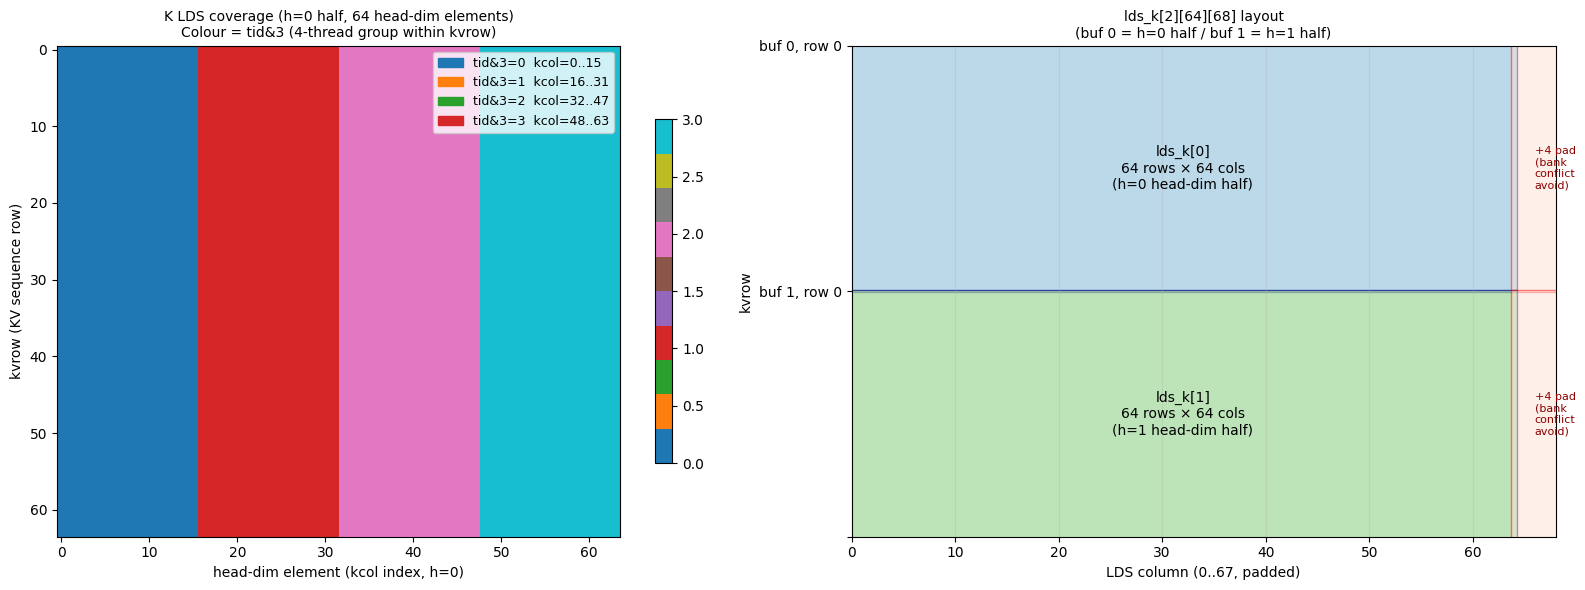

In [6]:
# Visualise the thread → (kvrow, kcol) mapping for K loading,
# and show how all elements of one K row are covered.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: for h=0, show which (kvrow, kcol) each thread writes in lds_k
# We use a 64×64 grid (kvrow × head-dim), colour = tid & 3 (the 4-thread group)
k_coverage = np.full((kNBlock, kHalfDim), -1, dtype=int)
for tid in range(kBlockSize):
    kvrow = tid >> 2
    kcol = (tid & 3) * 16
    grp = tid & 3
    # thread covers kcol..kcol+15
    k_coverage[kvrow, kcol : kcol + 16] = grp

ax = axes[0]
im = ax.imshow(
    k_coverage, aspect="auto", cmap="tab10", vmin=0, vmax=3, interpolation="nearest"
)
ax.set_title(
    "K LDS coverage (h=0 half, 64 head-dim elements)\nColour = tid&3 (4-thread group within kvrow)",
    fontsize=10,
)
ax.set_xlabel("head-dim element (kcol index, h=0)")
ax.set_ylabel("kvrow (KV sequence row)")
patches3 = [
    mpatches.Patch(
        color=plt.cm.tab10(i / 9), label=f"tid&3={i}  kcol={i * 16}..{i * 16 + 15}"
    )
    for i in range(4)
]
ax.legend(handles=patches3, fontsize=9, loc="upper right")
plt.colorbar(im, ax=ax, shrink=0.7)

# Right: lds_k layout showing the double-buffer + half-dim split
ax2 = axes[1]
ax2.set_xlim(0, kLdsStride)
ax2.set_ylim(0, kNBlock * 2)
ax2.invert_yaxis()
ax2.set_xlabel("LDS column (0..67, padded)")
ax2.set_ylabel("kvrow")
ax2.set_title(
    "lds_k[2][64][68] layout\n(buf 0 = h=0 half / buf 1 = h=1 half)", fontsize=10
)

for buf in range(2):
    y_off = buf * kNBlock
    color = "#9ecae1" if buf == 0 else "#a1d99b"
    rect = mpatches.FancyBboxPatch(
        (0, y_off),
        kHeadDim // 2,
        kNBlock,
        boxstyle="square",
        facecolor=color,
        edgecolor="navy",
        alpha=0.7,
    )
    ax2.add_patch(rect)
    ax2.text(
        kHeadDim // 4,
        y_off + kNBlock // 2,
        f"lds_k[{buf}]\n64 rows × 64 cols\n(h={buf} head-dim half)",
        ha="center",
        va="center",
        fontsize=10,
    )
    # show padding region
    pad_rect = mpatches.FancyBboxPatch(
        (kHalfDim, y_off),
        kLdsStride - kHalfDim,
        kNBlock,
        boxstyle="square",
        facecolor="#fee0d2",
        edgecolor="red",
        alpha=0.5,
    )
    ax2.add_patch(pad_rect)
    ax2.text(
        kHalfDim + 2,
        y_off + kNBlock // 2,
        "+4 pad\n(bank\nconflict\navoid)",
        ha="left",
        va="center",
        fontsize=8,
        color="darkred",
    )

ax2.set_yticks([0, kNBlock, kNBlock * 2])
ax2.set_yticklabels(["buf 0, row 0", f"buf 1, row 0", ""])
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6 · K LDS read during QK MFMA

```cpp
// K is split: lds_k[d>>2] is the LDS buffer (0=lo half, 1=hi half)
//             (d&3)*kKTile+4*quad selects the K-dim position within that buffer
bf16x4_t kf = *reinterpret_cast<const bf16x4_t*>(
    &lds_k[d >> 2][sn * kKTile + col][(d & 3) * kKTile + 4 * quad]);
```

Decomposed:

| index | expression | meaning |
|-------|-----------|--------|
| **buf** | `d >> 2` | which head-dim half (0 = elems 0–63, 1 = 64–127) |
| **row** | `sn * kKTile + col` | KV row: `sn` picks the 16-row sub-tile (0–3), `col` picks the row within it |
| **col** | `(d & 3) * kKTile + 4 * quad` | head-dim element within the half-buffer: `d&3` picks the 16-wide d-tile, `4*quad` picks the 4-element group |

This is **exactly the transposed B-matrix** view of K for the MFMA: the K matrix has shape `[KV-rows, head-dim]` and is read as B `[head-dim, KV-rows]^T` for the dot product `Q · K^T`.

/tmp/ipykernel_3847087/236263596.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_lds = plt.cm.get_cmap('tab20', kWaveSize)


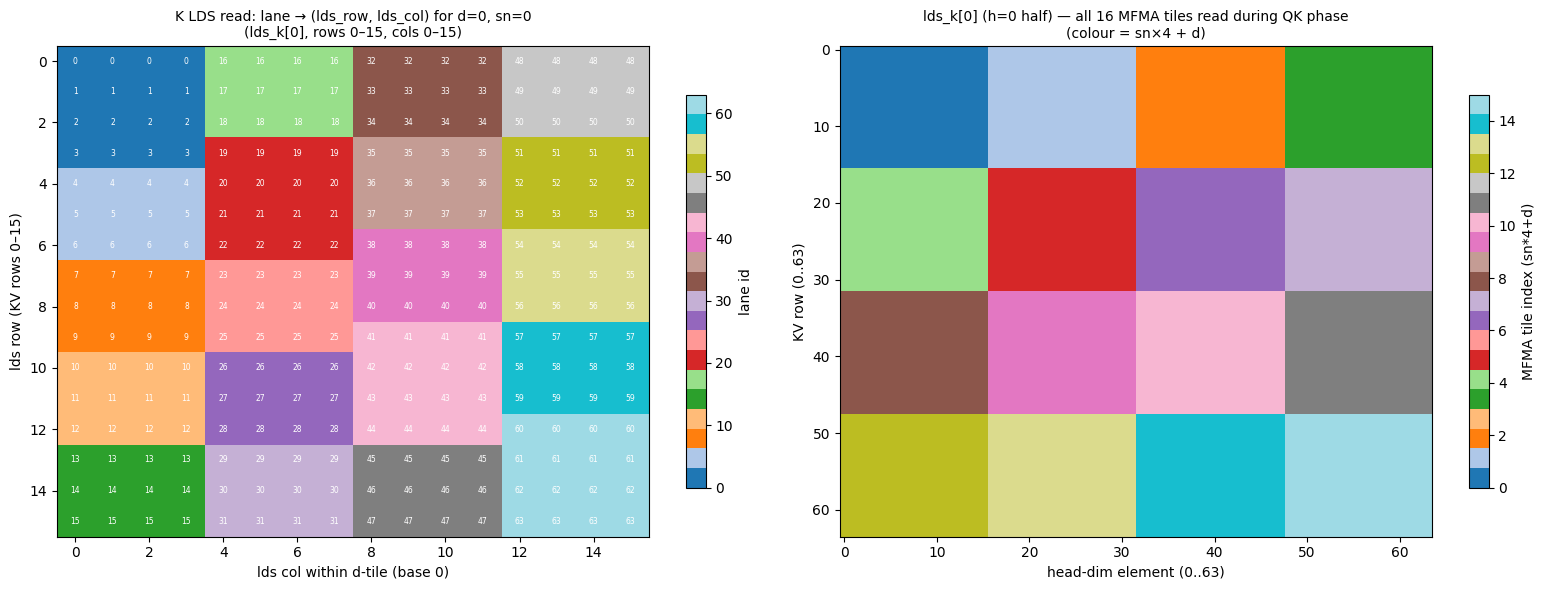

In [7]:
# For one (d, sn) pair, show which (lds_row, lds_col) each lane reads from lds_k
d_ex = 0  # d-tile index (0..7)
sn_ex = 0  # KV sub-tile (0..3)

k_read_row = np.zeros(kWaveSize, dtype=int)
k_read_col = np.zeros(kWaveSize, dtype=int)
for lane in range(kWaveSize):
    col = lane & 15
    quad = lane >> 4
    k_read_row[lane] = sn_ex * kKTile + col  # row in lds_k[buf]
    k_read_col[lane] = (d_ex & 3) * kKTile + 4 * quad  # col in lds_k[buf]

lds_access = np.full((kNBlock, kHalfDim), -1, dtype=int)
for lane in range(kWaveSize):
    for k in range(4):
        lds_access[k_read_row[lane], k_read_col[lane] + k] = lane

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
cmap_lds = plt.cm.get_cmap("tab20", kWaveSize)
# Zoom in on the active 16×16 tile
row0 = sn_ex * kKTile
col0 = (d_ex & 3) * kKTile
tile_view = lds_access[row0 : row0 + kKTile, col0 : col0 + kKTile]
im = ax.imshow(
    tile_view, aspect="auto", cmap="tab20", vmin=0, vmax=63, interpolation="nearest"
)
for r in range(kKTile):
    for c in range(kKTile):
        ax.text(
            c,
            r,
            str(tile_view[r, c]),
            ha="center",
            va="center",
            fontsize=5.5,
            color="white",
        )
ax.set_title(
    f"K LDS read: lane → (lds_row, lds_col) for d={d_ex}, sn={sn_ex}\n(lds_k[{d_ex >> 2}], rows {row0}–{row0 + 15}, cols {col0}–{col0 + 15})",
    fontsize=10,
)
ax.set_xlabel(f"lds col within d-tile (base {col0})")
ax.set_ylabel(f"lds row (KV rows {row0}–{row0 + 15})")
plt.colorbar(im, ax=ax, label="lane id", shrink=0.8)

# Right: big picture — all d-tiles in lds_k[0]
ax2 = axes[1]
big_map = np.full((kNBlock, kHalfDim), -1, dtype=float)
for sn in range(kNSub):
    for d in range(kDTiles // 2):  # kDTiles//2 = 4 d-tiles in buf 0
        for lane in range(kWaveSize):
            col_l = lane & 15
            quad_l = lane >> 4
            r = sn * kKTile + col_l
            c = (d & 3) * kKTile + 4 * quad_l
            for k in range(4):
                big_map[r, c + k] = sn * kDTiles // 2 + d  # colour by (sn, d) combo

im2 = ax2.imshow(
    big_map, aspect="auto", cmap="tab20", vmin=0, vmax=15, interpolation="nearest"
)
ax2.set_title(
    "lds_k[0] (h=0 half) — all 16 MFMA tiles read during QK phase\n(colour = sn×4 + d)",
    fontsize=10,
)
ax2.set_xlabel("head-dim element (0..63)")
ax2.set_ylabel("KV row (0..63)")
plt.colorbar(im2, ax=ax2, label="MFMA tile index (sn*4+d)", shrink=0.8)

plt.tight_layout()
plt.show()

---
## 7 · V transpose store

V must be accessed as `V^T` during the PV MFMA (P×V where P has shape `[Q-rows, KV-rows]`
and V has shape `[KV-rows, head-dim]`).  
To make V reads coalesced in LDS, V is **stored transposed**: columns become rows.

```
lds_v shape: [4][kKTile][kLdsStride]  =  [4 d-slabs][16 head-dim rows][68 KV columns]
```

Each thread loads 8 consecutive head-dim elements of one V row (`vdim..vdim+7`),
then scatters them across the 8 appropriate head-dim rows of `lds_v`.

```cpp
vdim = (tid & 3) * 8   // 0, 8, 16, 24  — which 8-element head-dim window

// pre-computed: which lds_v slab and intra-slab offset for each of the 4 chunks
vdt0 = vdim >> 4,         vdo0 = vdim & 15;         // chunk at vdim
vdt1 = (32+vdim) >> 4,    vdo1 = (32+vdim) & 15;    // chunk at vdim+32
vdt2 = ((64+vdim)>>4)-4,  vdo2 = (64+vdim) & 15;    // chunk at vdim+64  (buf reuse)
vdt3 = ((96+vdim)>>4)-4,  vdo3 = (96+vdim) & 15;    // chunk at vdim+96  (buf reuse)
```

The `vstore8` lambda then writes:
```cpp
lds_v[dt][d0 + i][kvrow] = src[i]   for i in 0..7
```
i.e. one thread writes **8 LDS cells, each in a different head-dim row, all in the same KV column** — a column-scatter that transposes V on the fly.

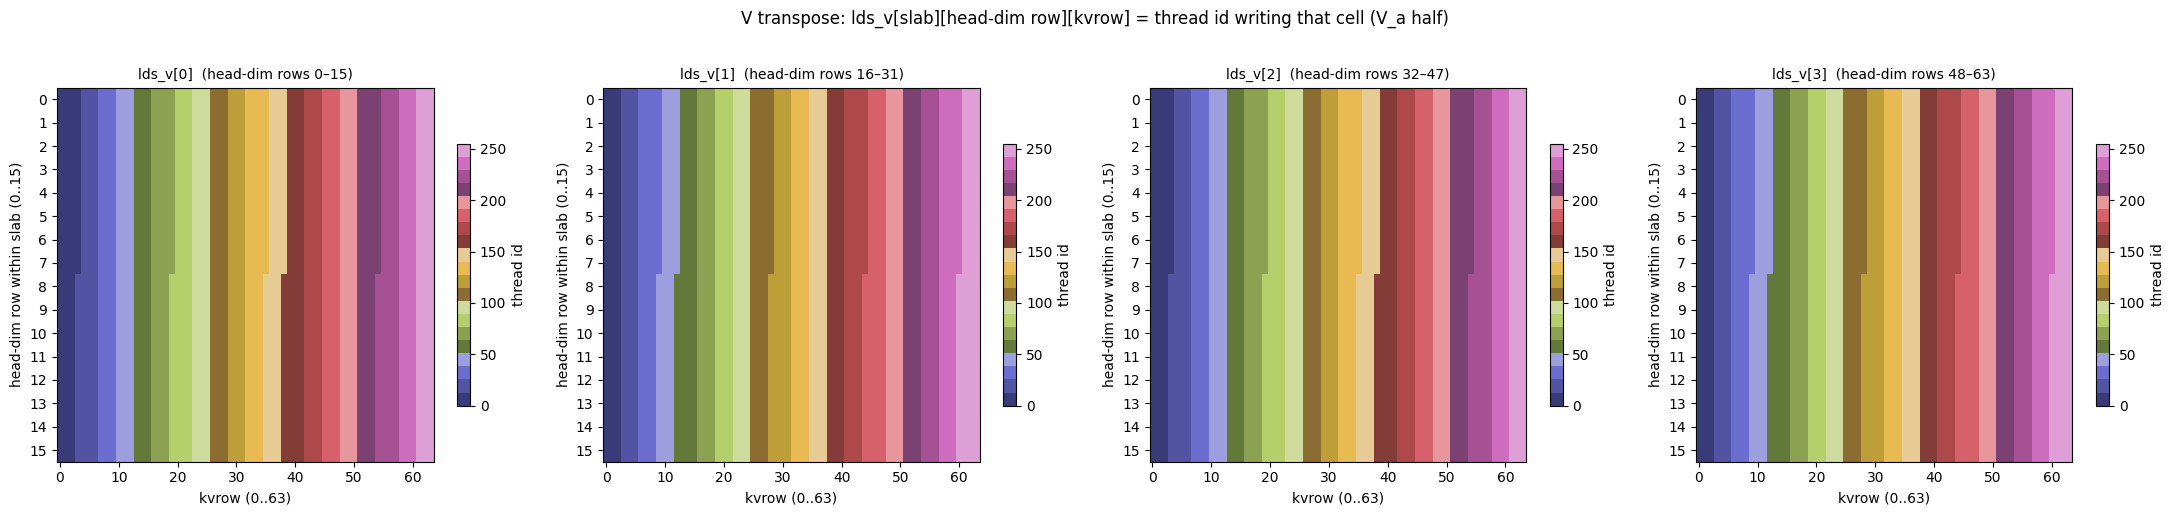

Each column (kvrow) is written by exactly one thread.
Each row (head-dim) is written by many threads, one per kvrow.
→ The KV dimension becomes the fast column axis, enabling coalesced reads during PV.


In [8]:
# Visualise which (lds_v slab, head-dim row, kvrow column) each thread writes
# for the V_a half (chunks at vdim and vdim+32)

# Build full lds_v for V_a stores (vstore8 for vdt0/vdo0 and vdt1/vdo1)
# lds_v[4][16][68] — we track thread id in each cell
lds_v_map = np.full((4, kKTile, kLdsStride), -1, dtype=int)

for tid in range(kBlockSize):
    kvrow = tid >> 2
    vdim = (tid & 3) * 8
    # V_a: va0 (vdim) and va1 (32+vdim)
    for chunk_base, dt_raw, do_raw in [
        (0, vdim >> 4, vdim & 15),
        (0, (32 + vdim) >> 4, (32 + vdim) & 15),
    ]:
        dt = dt_raw
        d0 = do_raw
        for i in range(8):
            row_in_slab = d0 + i
            if 0 <= dt < 4 and 0 <= row_in_slab < kKTile and 0 <= kvrow < kLdsStride:
                lds_v_map[dt][row_in_slab][kvrow] = tid

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for slab in range(4):
    ax = axes[slab]
    data = lds_v_map[slab, :, :kNBlock]  # show first 64 kvrow columns
    im = ax.imshow(
        data, aspect="auto", cmap="tab20b", vmin=0, vmax=255, interpolation="nearest"
    )
    ax.set_title(
        f"lds_v[{slab}]  (head-dim rows {slab * 16}–{slab * 16 + 15})", fontsize=10
    )
    ax.set_xlabel("kvrow (0..63)")
    ax.set_ylabel("head-dim row within slab (0..15)")
    ax.set_yticks(range(kKTile))
    plt.colorbar(im, ax=ax, label="thread id", shrink=0.7)

fig.suptitle(
    "V transpose: lds_v[slab][head-dim row][kvrow] = thread id writing that cell (V_a half)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

print("Each column (kvrow) is written by exactly one thread.")
print("Each row (head-dim) is written by many threads, one per kvrow.")
print(
    "→ The KV dimension becomes the fast column axis, enabling coalesced reads during PV."
)

---
## 8 · V LDS read during PV MFMA

```cpp
bf16x4_t vf = *reinterpret_cast<const bf16x4_t*>(
    &lds_v[dv][col][sn * kKTile + 4 * quad]);
```

| index | expression | meaning |
|-------|-----------|--------|
| **slab** | `dv ∈ {0,1,2,3}` | which 16-row head-dim slab (each slab = 16 head-dim rows) |
| **row** | `col = lane & 15` | which head-dim row within the slab (0..15) |
| **col** | `sn * kKTile + 4 * quad` | which KV-row group: `sn` picks the KV sub-tile (0..3), `quad` picks the 4-element group within it |

This reads V as `[head-dim, KV-rows]` — the transposed layout written above —
which is the B-matrix for the `P · V` MFMA where:
- A = P `[Q-rows × KV-rows]`, loaded from registers
- B = V `[KV-rows × head-dim]`, transposed in LDS → `[head-dim × KV-rows]`
- D = O `[Q-rows × head-dim]`, accumulated in registers

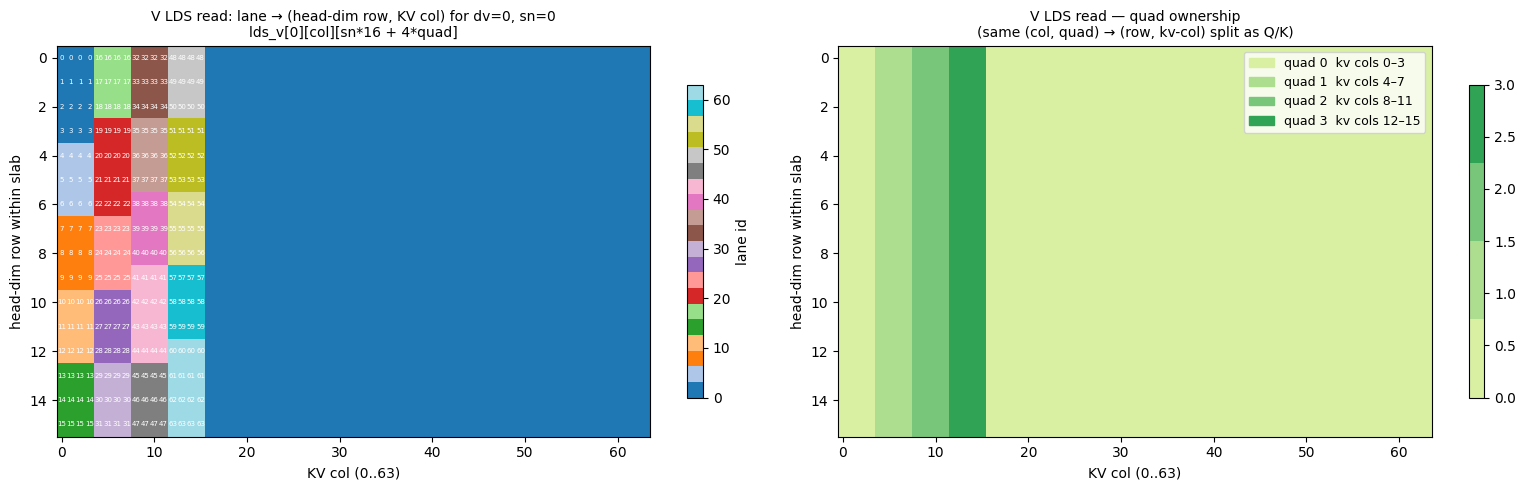

In [9]:
# For slab dv=0, sn=0: which (head-dim row, KV col) each lane reads
dv_ex = 0
sn_ex = 0

v_read = np.full((kKTile, kNBlock), -1, dtype=int)
for lane in range(kWaveSize):
    col_l = lane & 15
    quad_l = lane >> 4
    row_l = col_l  # head-dim row in slab
    kv_start = sn_ex * kKTile + 4 * quad_l  # KV col start
    for k in range(4):
        v_read[row_l, kv_start + k] = lane

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
im = ax.imshow(
    v_read, aspect="auto", cmap="tab20", vmin=0, vmax=63, interpolation="nearest"
)
for r in range(kKTile):
    for c in range(kNBlock):
        if v_read[r, c] >= 0:
            ax.text(
                c,
                r,
                str(v_read[r, c]),
                ha="center",
                va="center",
                fontsize=5,
                color="white",
            )
ax.set_title(
    f"V LDS read: lane → (head-dim row, KV col) for dv={dv_ex}, sn={sn_ex}\nlds_v[{dv_ex}][col][sn*16 + 4*quad]",
    fontsize=10,
)
ax.set_xlabel("KV col (0..63)")
ax.set_ylabel("head-dim row within slab")
plt.colorbar(im, ax=ax, label="lane id", shrink=0.8)

# Right: show the duality — same (col, quad) pattern as in Q/K, just for V
ax2 = axes[1]
quad_vread = v_read >> 4
quad_vread[v_read < 0] = -1
cmap_q = ListedColormap(["#d9f0a3", "#addd8e", "#78c679", "#31a354"])
im2 = ax2.imshow(
    quad_vread, aspect="auto", cmap=cmap_q, vmin=0, vmax=3, interpolation="nearest"
)
ax2.set_title(
    "V LDS read — quad ownership\n(same (col, quad) → (row, kv-col) split as Q/K)",
    fontsize=10,
)
ax2.set_xlabel("KV col (0..63)")
ax2.set_ylabel("head-dim row within slab")
patches4 = [
    mpatches.Patch(color=cmap_q(i / 3), label=f"quad {i}  kv cols {i * 4}–{i * 4 + 3}")
    for i in range(4)
]
ax2.legend(handles=patches4, fontsize=9)
plt.colorbar(im2, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

---
## 9 · Output store — epilogue

```cpp
bst8(or_, ((qbase[qg] + col) * kHeadDim + t * kKTile + 4 * quad) * 2, out);
```

This is the **exact mirror** of the Q load (Section 3):

| Q load | O store |
|--------|---------|
| `(qbase[qg] + col) * kHeadDim` | same row index |
| `d * kKTile + 4 * quad` | `t * kKTile + 4 * quad` (same formula, `d` renamed `t`) |
| `* 2` | same byte scale |

The only new step is the **softmax normalisation** before packing:
```cpp
const float inv = rcpf(l[qg]);    // 1 / row-sum
bf16x4_t out = pack4_bf16(o[qg][t][0]*inv, o[qg][t][1]*inv,
                           o[qg][t][2]*inv, o[qg][t][3]*inv);
```

Each lane writes 4 normalised output values back to the same (row, head-dim) position it originally read Q from — the memory access pattern is perfectly symmetric.

In [10]:
# Confirm symmetry: Q load byte offsets == O store byte offsets for the same lane/tile
errors = 0
for qg in range(2):
    qbase = qg * kKTile  # toy: tile 0 → qbase=0, tile 1 → qbase=16
    for lane in range(kWaveSize):
        col = lane & 15
        quad = lane >> 4
        for d in range(kDTiles):
            load_off = ((qbase + col) * kHeadDim + d * kKTile + 4 * quad) * 2
            store_off = ((qbase + col) * kHeadDim + d * kKTile + 4 * quad) * 2
            if load_off != store_off:
                errors += 1

print(f"Q-load vs O-store offset mismatches: {errors}  (expected 0 — perfect symmetry)")

Q-load vs O-store offset mismatches: 0  (expected 0 — perfect symmetry)


---
## 10 · Full index arithmetic summary

All index expressions in the kernel reduce to one of two patterns:

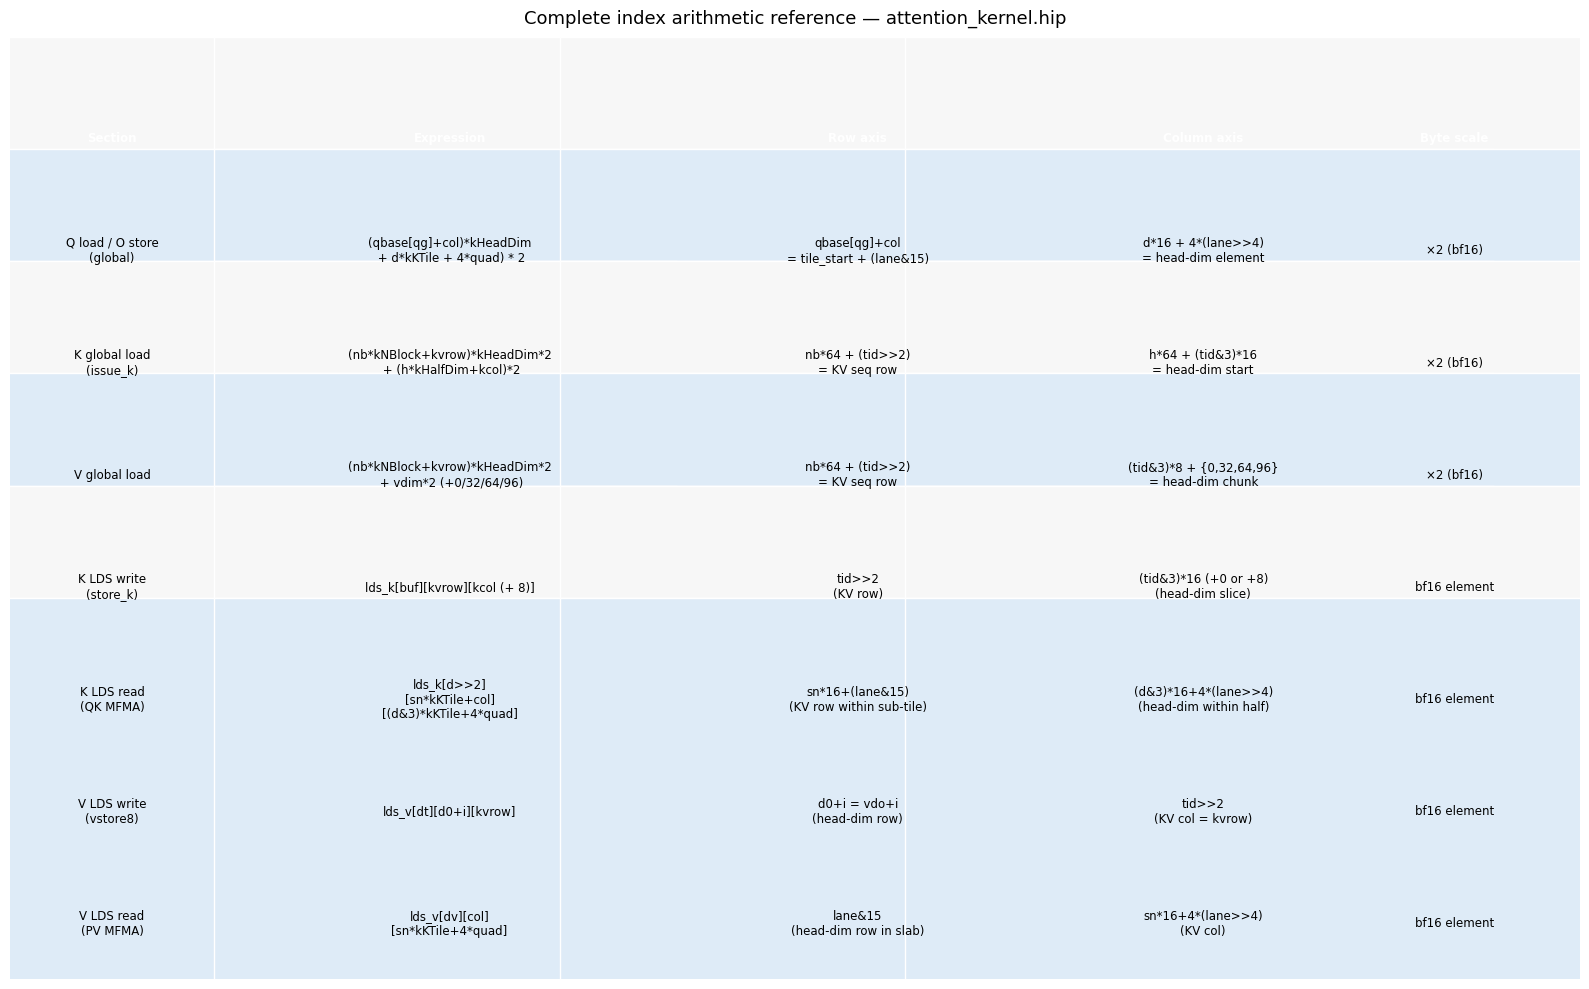

In [11]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")

rows = [
    ["Section", "Expression", "Row axis", "Column axis", "Byte scale"],
    [
        "Q load / O store\n(global)",
        "(qbase[qg]+col)*kHeadDim\n + d*kKTile + 4*quad) * 2",
        "qbase[qg]+col\n= tile_start + (lane&15)",
        "d*16 + 4*(lane>>4)\n= head-dim element",
        "×2 (bf16)",
    ],
    [
        "K global load\n(issue_k)",
        "(nb*kNBlock+kvrow)*kHeadDim*2\n + (h*kHalfDim+kcol)*2",
        "nb*64 + (tid>>2)\n= KV seq row",
        "h*64 + (tid&3)*16\n= head-dim start",
        "×2 (bf16)",
    ],
    [
        "V global load",
        "(nb*kNBlock+kvrow)*kHeadDim*2\n + vdim*2 (+0/32/64/96)",
        "nb*64 + (tid>>2)\n= KV seq row",
        "(tid&3)*8 + {0,32,64,96}\n= head-dim chunk",
        "×2 (bf16)",
    ],
    [
        "K LDS write\n(store_k)",
        "lds_k[buf][kvrow][kcol (+ 8)]",
        "tid>>2\n(KV row)",
        "(tid&3)*16 (+0 or +8)\n(head-dim slice)",
        "bf16 element",
    ],
    [
        "K LDS read\n(QK MFMA)",
        "lds_k[d>>2]\n[sn*kKTile+col]\n[(d&3)*kKTile+4*quad]",
        "sn*16+(lane&15)\n(KV row within sub-tile)",
        "(d&3)*16+4*(lane>>4)\n(head-dim within half)",
        "bf16 element",
    ],
    [
        "V LDS write\n(vstore8)",
        "lds_v[dt][d0+i][kvrow]",
        "d0+i = vdo+i\n(head-dim row)",
        "tid>>2\n(KV col = kvrow)",
        "bf16 element",
    ],
    [
        "V LDS read\n(PV MFMA)",
        "lds_v[dv][col]\n[sn*kKTile+4*quad]",
        "lane&15\n(head-dim row in slab)",
        "sn*16+4*(lane>>4)\n(KV col)",
        "bf16 element",
    ],
]

col_widths = [0.13, 0.30, 0.22, 0.22, 0.10]
col_starts = [0] + list(np.cumsum(col_widths[:-1]))

header_color = "#2171b5"
row_colors = ["#f7f7f7", "#deebf7"]

for ri, row in enumerate(rows):
    for ci, (cell, w, x) in enumerate(zip(row, col_widths, col_starts)):
        y = 1.0 - ri * (1.0 / len(rows))
        h = 1.0 / len(rows)
        bg = header_color if ri == 0 else row_colors[ri % 2]
        fc = "white" if ri == 0 else "black"
        rect = mpatches.FancyBboxPatch(
            (x, y - h),
            w - 0.005,
            h,
            boxstyle="square",
            facecolor=bg,
            edgecolor="white",
            linewidth=1,
        )
        ax.add_patch(rect)
        ax.text(
            x + w / 2,
            y - h / 2,
            cell,
            ha="center",
            va="center",
            fontsize=8.5,
            color=fc,
            fontweight="bold" if ri == 0 else "normal",
            multialignment="center",
        )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title(
    "Complete index arithmetic reference — attention_kernel.hip", fontsize=13, pad=10
)
plt.tight_layout()
plt.show()